<a href="https://colab.research.google.com/github/shanshiny06/econ3916-lab05-monte-carlo/blob/main/%E2%80%9Clab_ch05_guided_ipynb%E2%80%9D%E7%9A%84%E5%89%AF%E6%9C%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 5: Monte Carlo Engine
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 8 min Part 0 + 35 min Core + 15 min Extension

---

**Learning Objectives:**
- Run and read Monte Carlo simulations written with the NumPy Generator API
- Apply Bayes' Theorem to a real-world screening problem
- Estimate Value at Risk and Expected Shortfall for a portfolio
- Visualize the Law of Large Numbers convergence

**Chapter Reference:** Chapter 5 — Probability and Simulation: From Uncertainty to Decisions

**How this lab works:** Parts 0, 1 and 3 are GUIDED: run each cell as it is, then answer the questions. Parts 2 and 4 work the same way, with six short blanks to fill in. The Extension and "Write it yourself" are optional.

**Prerequisites:** Part 0 of this lab (below), plus Chapter 5 reading (probability axioms, Bayes' Theorem, Monte Carlo simulation, VaR/ES)

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

---

> ### What you write, and what you run
>
> **You write:**
> - **Part 2, Step 4:** two blanks (`____`) in the Monty Hall loop, one line each.
> - **Part 4, Steps 9 and 10:** four blanks, one line each: the simulated returns, two percentiles, and the cutoff for the worst days.
> - The answers to the interpretation questions after each part, in text cells.
> - **The AI Expansion:** you revise the given prompt once, and write four short answers about the AI's function, including a check against your own Step 10 numbers.
>
> **You run and read:** everything else. Part 0, Parts 1 and 3, the rest of Parts 2 and 4, and the Extension are working code to learn from. Read each cell before you run it, and make sure you can say what each line does.
>
> **Code you write yourself:** "Optional: Write it yourself", after Part 4. About five lines from a blank cell, and a check cell tells you whether they work. It is optional this week and not graded. Writing code from a blank cell is what Problem Set 1 grades; its ungraded warm-up, linked from the PS1 assignment, is the practice.

## Setup

<!-- idiom-note -->
> ### New idiom — NumPy arrays, seeds, and drawing random numbers
>
> **NumPy** gives Python fast numeric arrays. An array looks like a list, but
> arithmetic applies to every element at once — `arr * 2` doubles the whole
> thing with no loop. Nearly every number in this course sits in one
> underneath, including inside pandas.
>
> A **seed** is where the random number generator starts. Randomness here is
> not really random: it is a fixed sequence, and the seed says where to begin.
> That is why a seed sits at the top of every lab — you, your classmate, and
> your grader draw the *same* "random" numbers, so results reproduce. The
> number 42 is a convention, nothing more. You will see two spellings: the
> older `np.random.seed(42)`, and the modern **Generator** form this lab uses,
> `rng = np.random.default_rng(42)`. Prefer the modern one; it is the reason
> every draw below is written `rng.something(...)` rather than
> `np.random.something(...)`.
>
> Three lines you will read constantly from here on:
>
> ```python
> rng = np.random.default_rng(42)     # a generator, seeded
> rng.normal(0, 1, size=100)          # 100 draws; also .binomial, .poisson, .lognormal
> np.where(cond, a, b)                # "a where cond is True, else b" — for a whole array at once
> ```
>
> `np.where` is an if/else applied to every element simultaneously. It is the
> vectorised version of the one-line `if`/`else` you will meet in Lab 8.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# One seeded generator for every random draw in Parts 1-4 (see the note above)
rng = np.random.default_rng(seed=42)

plt.style.use("seaborn-v0_8-whitegrid")

<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 8 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** NumPy arrays, the random seed, and counting inside a `for` loop.

Everything in this lab rests on random draws, which means it rests on NumPy —
and on reproducibility. Reproducible means your classmate gets your numbers.

Some notation you will meet in almost every cell:

- `10_000` is just 10000. Python ignores the underscore; it is there to make big numbers readable.
- In an f-string, what follows the colon sets the format: `{x:,}` adds thousands commas,
  `{x:.4f}` shows 4 decimals, and `{x:.1%}` shows a share as a percent (0.506 becomes 50.6%).
- `\n` inside a string starts a new line.
- A comparison such as `x < 0.5` on an array gives True or False for every element. Python
  counts True as 1 and False as 0, so `.sum()` counts the Trues and `.mean()` is the share
  that is True.

The last part of the cell counts coin flips twice: once in a `for` loop, which is easy to
read and is the shape of the Monty Hall loop in Part 2, and once on a whole array, which is
how the rest of the lab runs.

In [2]:
# GUIDED — run as-is
# Step 0: NumPy arrays, the seed, and counting in a loop

# An array does arithmetic on every element at once, with no loop
a = np.array([1.0, 2.0, 3.0, 4.0])
print("array:      ", a)
print("a * 2:      ", a * 2)
print("mean, std:  ", a.mean(), a.std().round(4))

# The same seed gives the same "random" numbers. This is the older spelling; later parts use rng
np.random.seed(42)
first = np.random.normal(0, 1, 3)
np.random.seed(42)
second = np.random.normal(0, 1, 3)
print(f"\nSame seed, same draws: {np.allclose(first, second)}")   # allclose: do the two arrays match?
print("  ", first.round(4))

# for _ in range(n) means "do this n times"; _ names a value we never use
np.random.seed(0)
wins = 0
for _ in range(10_000):
    if np.random.random() < 0.5:      # a number between 0 and 1 is below 0.5 half the time
        wins += 1                     # add one to wins
print(f"\n10,000 fair coin flips: {wins:,} heads ({wins / 10_000:.1%})")

# The same experiment on a whole array at once
np.random.seed(0)
flips = np.random.random(10_000) < 0.5
print(f"Same thing, vectorised: {flips.sum():,} heads ({flips.mean():.1%})")

array:       [1. 2. 3. 4.]
a * 2:       [2. 4. 6. 8.]
mean, std:   2.5 1.118

Same seed, same draws: True
   [ 0.4967 -0.1383  0.6477]

10,000 fair coin flips: 5,064 heads (50.6%)
Same thing, vectorised: 5,064 heads (50.6%)


---

## Part 1: Coin Flip Convergence — The Law of Large Numbers (GUIDED — 9 min)

The **Law of Large Numbers (LLN)** guarantees that as the number of independent trials grows, the sample mean converges to the expected value. This is *why* Monte Carlo simulation works.

We start with the simplest possible simulation: fair coin flips. The true probability of heads is 0.5. How many flips does it take for the running proportion to stabilize near 0.5?

In [3]:
# GUIDED — run as-is
# Step 1: simulate 10,000 fair coin flips

n_flips = 10_000

# A binomial draw with n=1 is one coin flip: the same coin flip as random() < 0.5 in Step 0, recorded as 1 or 0
flips = rng.binomial(n=1, p=0.5, size=n_flips)

cumulative_heads = np.cumsum(flips)          # running total: heads so far, after each flip
flip_number = np.arange(1, n_flips + 1)      # 1, 2, ..., 10000 (arange leaves out its end)
running_proportion = cumulative_heads / flip_number

print(f"Total flips: {n_flips:,}")
print(f"Total heads: {flips.sum():,} ({flips.mean():.4f})")
print()
print("Running proportion at key milestones:")
# Position n-1 holds flip n, because positions count from 0; >6 right-aligns the number
for n in [10, 50, 100, 500, 1000, 5000, 10000]:
    print(f"  After {n:>6,} flips: {running_proportion[n-1]:.4f}")

Total flips: 10,000
Total heads: 4,985 (0.4985)

Running proportion at key milestones:
  After     10 flips: 0.6000
  After     50 flips: 0.5000
  After    100 flips: 0.4700
  After    500 flips: 0.5020
  After  1,000 flips: 0.4970
  After  5,000 flips: 0.4910
  After 10,000 flips: 0.4985


**Expected output:** The proportion starts noisy (could be 0.60 or 0.40 after 10 flips) and gradually tightens around 0.50. It is not a straight path: this run hits 0.5000 at flip 50, then wanders away to 0.4700 by flip 100. By 10,000 flips, the proportion should be within 0.01 of the true value.

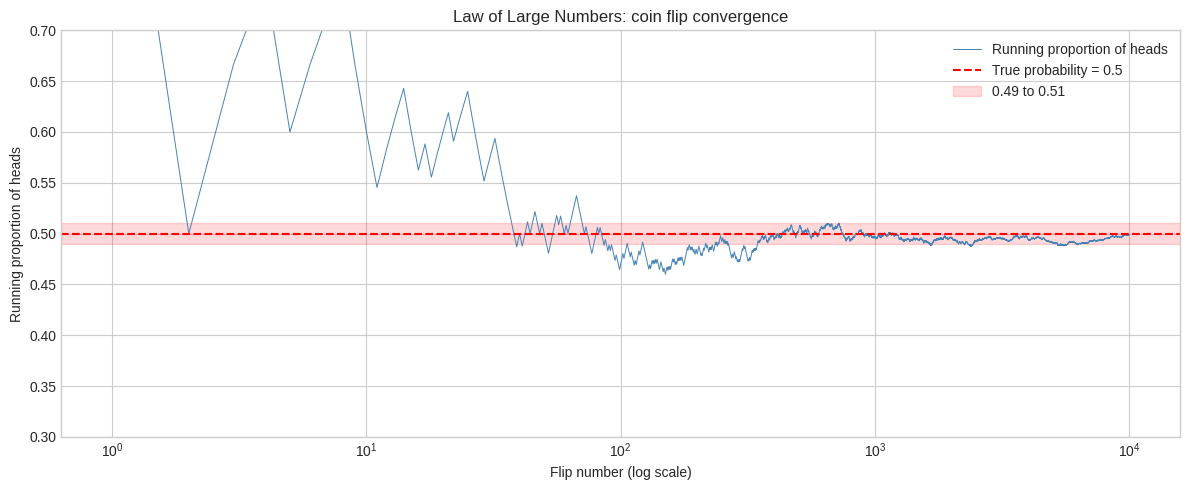

The running proportion stays within 0.01 of 0.5 from flip 6,455 onward.


In [4]:
# GUIDED — run as-is
# Step 2: plot the running proportion, and find where it settles

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(flip_number, running_proportion, linewidth=0.7, color="steelblue",
        label="Running proportion of heads")
ax.axhline(0.5, color="red", linestyle="--", label="True probability = 0.5")
ax.axhspan(0.49, 0.51, alpha=0.15, color="red", label="0.49 to 0.51")
ax.set_xscale("log")    # a log axis gives the first 100 flips as much room as the last 9,000
ax.set_xlabel("Flip number (log scale)")
ax.set_ylabel("Running proportion of heads")
ax.set_title("Law of Large Numbers: coin flip convergence")
ax.set_ylim(0.3, 0.7)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# np.abs gives the distance from 0.5, above or below; True where it is more than 0.01
outside_band = np.abs(running_proportion - 0.5) > 0.01
# flip_number[outside_band] keeps the flip numbers where outside_band is True
last_outside = flip_number[outside_band].max()
print(f"The running proportion stays within 0.01 of 0.5 from flip {last_outside + 1:,} onward.")

### Interpretation Questions

**Q1:** At approximately what sample size does the running proportion stay within 0.01 of 0.5 (one percentage point)? What does this tell you about the minimum number of observations you need before trusting a sample proportion?

**Q2:** If this were a poll instead of a coin flip (e.g., proportion of voters supporting a candidate), what would LLN imply about the minimum sample size for a reliable poll?

**Q3:** (Callback to Ch 4) The sample mean of a Bernoulli trial *is* the sample proportion. Is this sample mean robust or non-robust? Why does LLN still work despite the mean's sensitivity to outliers?

*Your answers here:*

1. The running proportion first enters the 0.49 to 0.51 band at roughly 400 to 500 flips, but it still wanders outside that band briefly around the 1,000 to 2,000 flip mark before settling in more permanently from around 2,000 to 3,000 flips onward. This tells us that a sample proportion needs several hundred to a few thousand observations before it becomes a reliably trustworthy estimate of the true underlying probability. Early on, with only a handful of flips, the proportion swings wildly because a few lucky or unlucky outcomes dominate a tiny sample, and only as the sample size grows into the hundreds and thousands does the Law of Large Numbers consistently pull the running average toward the true value and keep it there.
2. LLN implies that a poll needs a sufficiently large sample size before its reported proportion can be trusted as a reliable estimate of the true population support, for the same reason a small number of coin flips gives an unreliable estimate of the true 50% probability. A poll based on only a handful of respondents could easily show a wildly inaccurate result purely by chance, just as a few early coin flips can drift far from 0.5, and only as the number of respondents grows large does the sample proportion reliably converge toward the true proportion of voters who support the candidate. This is why credible polls report sample sizes in the hundreds or thousands rather than relying on a tiny handful of respondents.
3. The sample mean of a Bernoulli trial is non-robust, in the same sense discussed in Chapter 4: the mean is sensitive to every individual observation, and a single extreme or unusual value can shift it. However, LLN still works here despite that sensitivity because a Bernoulli trial only ever takes the values 0 or 1, there is no possibility of an extreme outlier value like a corrupted entry of 1,000,000 distorting the average the way there could be with continuous data. Since every single observation is bounded to exactly 0 or 1, the non-robustness of the mean never gets a chance to cause damage here, and as the number of flips grows large, the proportion of 1s simply converges to the true underlying probability exactly as LLN predicts.

---

## Part 2: Monty Hall Simulation (GUIDED + YOUR TASK — 8 min)

The **Monty Hall Problem:** You are on a game show. Three doors: one hides a car, two hide goats. You pick a door. The host (who knows what is behind each door) opens a different door, always revealing a goat. Should you switch or stay?

Most people say it does not matter. Steps 3 and 4 play 10,000 games each way and count the wins.

In [5]:
# GUIDED — run as-is
# Step 3: Monty Hall, the "always stay" strategy

n_games = 10_000

# The car's door in each game: 0, 1 or 2 (integers leaves out its upper end, 3)
car_door = rng.integers(0, 3, size=n_games)

# The player always picks door 0; any fixed pick has the same odds, because the car is random
player_choice = np.zeros(n_games, dtype=int)     # 10,000 zeros, as whole numbers

# Staying wins exactly when the car is behind the first pick
stay_wins = (car_door == player_choice).sum()

print("Strategy: ALWAYS STAY")
print(f"Wins: {stay_wins:,} out of {n_games:,}")
print(f"Win rate: {stay_wins / n_games:.4f}")
print(f"Expected (theoretical): {1/3:.4f}")

Strategy: ALWAYS STAY
Wins: 3,306 out of 10,000
Win rate: 0.3306
Expected (theoretical): 0.3333


<!-- idiom-note -->
> ### New idiom — picking items from a list by a rule
>
> In Step 4 the host picks his door with this line:
>
> ```python
> available_to_host = [d for d in range(3) if d != player and d != car]
> ```
>
> Read it left to right: "each door `d` out of 0, 1 and 2, keeping it only if it is not
> the player's pick **and** not the car". `!=` means "is not equal to", and `==` means
> "is equal to" (a single `=` stores a value instead). The result is a **list**, even when
> only one door is kept: `[2]`, not `2`. To get the item itself, ask for position 0:
> `[2][0]` is `2`.
>
> `rng.choice(some_list)` then picks one item from the list at random.

In [25]:
# YOUR TASK — fill in the two blanks (____)
# Step 4: Monty Hall, the "always switch" strategy

switch_wins = 0

for i in range(n_games):
    car = car_door[i]
    player = player_choice[i]

    # The host knows where the car is, so he never opens the car's door or the player's
    available_to_host = [d for d in range(3) if d != player and d != car]
    host_opens = rng.choice(available_to_host)

    # Blank 1: the door you switch to, the only one left. The note above shows how to pick by a rule
    switched_door = [d for d in range(3) if d != player and d != host_opens][0]

    # Blank 2: when does switching win this game?
    if switched_door == car:
     switch_wins += 1

print("Strategy: ALWAYS SWITCH")
print(f"Wins: {switch_wins:,} out of {n_games:,}")
print(f"Win rate: {switch_wins / n_games:.4f}")
print(f"Expected (theoretical): {2/3:.4f}")

Strategy: ALWAYS SWITCH
Wins: 6,694 out of 10,000
Win rate: 0.6694
Expected (theoretical): 0.6667


**Expected output:** a win rate near 0.6667. A win rate of exactly 0.0000 usually means
`switched_door` holds a list, and a list is never equal to a door number: see the note above
Step 4. *NameError: name '____' is not defined* means a blank is still empty.

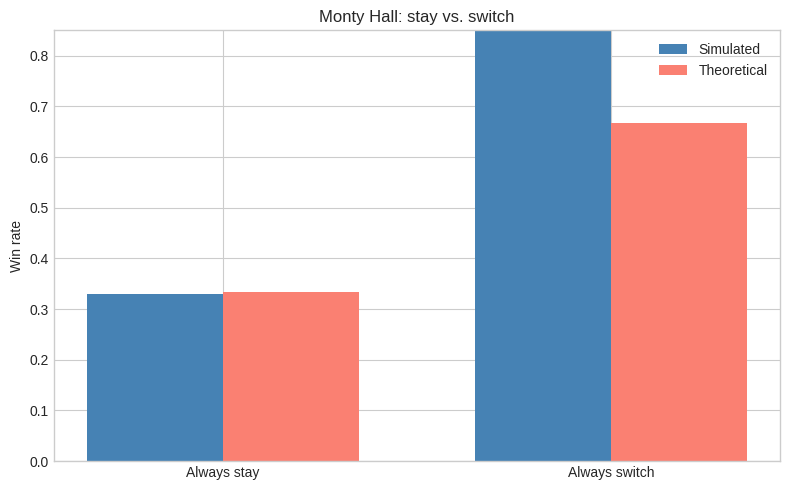

Switching wins 3.0x as often as staying.


In [7]:
# GUIDED — run as-is, once the blanks in Step 4 are filled in
# Step 5: compare the two strategies

strategies = ["Always stay", "Always switch"]
simulated = [stay_wins / n_games, switch_wins / n_games]
theoretical = [1/3, 2/3]

# Two bars per strategy: the simulated bar shifted left, the theoretical bar shifted right
x = np.arange(len(strategies))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, simulated, width, label="Simulated", color="steelblue")
ax.bar(x + width/2, theoretical, width, label="Theoretical", color="salmon")
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.set_ylabel("Win rate")
ax.set_title("Monty Hall: stay vs. switch")
ax.set_ylim(0, 0.85)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Switching wins {switch_wins / stay_wins:.1f}x as often as staying.")

### Interpretation Questions

**Q1:** Why is switching optimal? Connect your answer to *conditional probability* — what information does the host's action give you?

**Q2:** Many people (including PhD mathematicians!) initially believe switching does not help. Why is this problem so counterintuitive? What assumption does your intuition make that is wrong?

**Q3:** If the host opened a door *at random* (possibly revealing the car), would switching still be optimal? Why or why not?

*Your answers here:*

1. Switching is optimal because the host's action is not random, it is informed. When you first pick a door, you have a 1/3 chance of being right and a 2/3 chance the car is behind one of the other two doors. The host, who knows where the car is, is then forced to open a door from those remaining two that he knows does NOT have the car. This means the host's action transfers all of that original 2/3 probability onto the single door he leaves closed, rather than splitting it evenly. Conditional on the host's specific choice (he could only reveal a goat, never the car), the unopened door you did not originally pick now carries the full 2/3 probability, while your original pick is still stuck at 1/3, which is exactly why switching doubles your odds.
2. This problem is so counterintuitive because our intuition tends to treat the situation as if it resets to a fresh 50/50 coin flip once one door is eliminated, as though the two remaining doors must now be equally likely simply because there are two of them left. The flawed assumption is that the host's action is uninformative, as if he opened a door at random and just happened not to reveal the car. In reality, the host's choice is constrained and deliberate: he always avoids both your door and the car, so his action carries information that updates the probabilities unevenly between the two remaining doors rather than splitting them equally.
3. No, switching would no longer be the optimal, information-rich strategy in the same way. If the host opens a door at random, there are now two distinct scenarios: either he accidentally reveals the car, ending the game immediately, or he happens to reveal a goat. Conditioning only on the games where a goat happens to be revealed, switching and staying would actually become equally good, each winning with 1/2 probability, because the host's reveal in that case carries no special information about which door was deliberately avoided. The entire advantage of switching in the original problem comes specifically from the host's guaranteed, informed avoidance of the car, and that advantage disappears once the host's action is random rather than deliberate.

---

## Part 3: Bayes' Theorem — Disease Screening (GUIDED — 8 min)

A medical screening test has:
- **Prevalence** (base rate): 1% of the population has the disease
- **Sensitivity**: 95% (test correctly detects 95% of sick people)
- **Specificity**: 90% (test correctly clears 90% of healthy people)

You test positive. What is the probability you are actually sick?

Most people guess 90-95%. Step 6 computes it.

In [8]:
# GUIDED — run as-is
# Step 6: Bayes' Theorem, by formula

prevalence = 0.01                        # P(Sick)
sensitivity = 0.95                       # P(Positive | Sick)
specificity = 0.90                       # P(Negative | Healthy)
false_positive_rate = 1 - specificity    # P(Positive | Healthy)

# A positive test comes from a sick person caught, or a healthy person wrongly flagged
p_positive = sensitivity * prevalence + false_positive_rate * (1 - prevalence)

# Bayes' Theorem: of all the positives, the share who are sick
posterior = sensitivity * prevalence / p_positive

print("Given:")
print(f"  P(Sick)               = {prevalence:.4f}  (prevalence)")
print(f"  P(Positive | Sick)    = {sensitivity:.4f}  (sensitivity)")
print(f"  P(Positive | Healthy) = {false_positive_rate:.4f}  (false positive rate)")
print()
print(f"P(Positive) = {sensitivity}*{prevalence} + {false_positive_rate:.4f}*{1-prevalence}")
print(f"            = {sensitivity*prevalence:.4f} + {false_positive_rate*(1-prevalence):.4f}")
print(f"            = {p_positive:.4f}")
print()
print(f"P(Sick | Positive) = ({sensitivity} * {prevalence}) / {p_positive:.4f}")
print(f"                   = {sensitivity*prevalence:.4f} / {p_positive:.4f}")
print(f"                   = {posterior:.4f}")
print()
print(f"Positives who are sick:    {posterior:.1%}")
print(f"Positives who are healthy: {1 - posterior:.1%}")

Given:
  P(Sick)               = 0.0100  (prevalence)
  P(Positive | Sick)    = 0.9500  (sensitivity)
  P(Positive | Healthy) = 0.1000  (false positive rate)

P(Positive) = 0.95*0.01 + 0.1000*0.99
            = 0.0095 + 0.0990
            = 0.1085

P(Sick | Positive) = (0.95 * 0.01) / 0.1085
                   = 0.0095 / 0.1085
                   = 0.0876

Positives who are sick:    8.8%
Positives who are healthy: 91.2%


**Expected output:** P(Sick | Positive) is approximately 0.0876 (8.8%). The other 91.2% of positive tests are false alarms. A test that catches 95% of sick people still gives mostly false alarms when the disease is rare. This is the **base rate fallacy** from Chapter 5.

In [9]:
# GUIDED — run as-is
# Step 7: simulate 100,000 people to check Bayes' Theorem

n_people = 100_000

# rng.random draws between 0 and 1, so "< prevalence" is True for about 1% of people
is_sick = rng.random(n_people) < prevalence

# np.where (note under Setup): sick people test positive at the sensitivity, healthy ones at the false positive rate
test_positive = np.where(
    is_sick,
    rng.random(n_people) < sensitivity,
    rng.random(n_people) < false_positive_rate,
)

# & means "and": tested positive and is sick
true_positives = (test_positive & is_sick).sum()
total_positives = test_positive.sum()
simulated_posterior = true_positives / total_positives

print(f"Actually sick:   {is_sick.sum():>7,} ({is_sick.mean():.2%})")
print(f"Tested positive: {total_positives:>7,} ({test_positive.mean():.2%})")
print(f"True positives:  {true_positives:>7,}")
print(f"False positives: {total_positives - true_positives:>7,}")
print()
print(f"Simulated  P(Sick | Positive): {simulated_posterior:.4f}")
print(f"Analytical P(Sick | Positive): {posterior:.4f}")
print(f"Difference: {abs(simulated_posterior - posterior):.4f}")

Actually sick:     1,058 (1.06%)
Tested positive:  10,847 (10.85%)
True positives:      997
False positives:   9,850

Simulated  P(Sick | Positive): 0.0919
Analytical P(Sick | Positive): 0.0876
Difference: 0.0044


**Expected output:** 1,058 of the 100,000 people are sick, and 10,847 test positive. Only 997
of those positives are sick. The simulated 0.0919 is close to the formula's 0.0876; the gap of
0.0044 is sampling noise, and it shrinks as `n_people` grows.

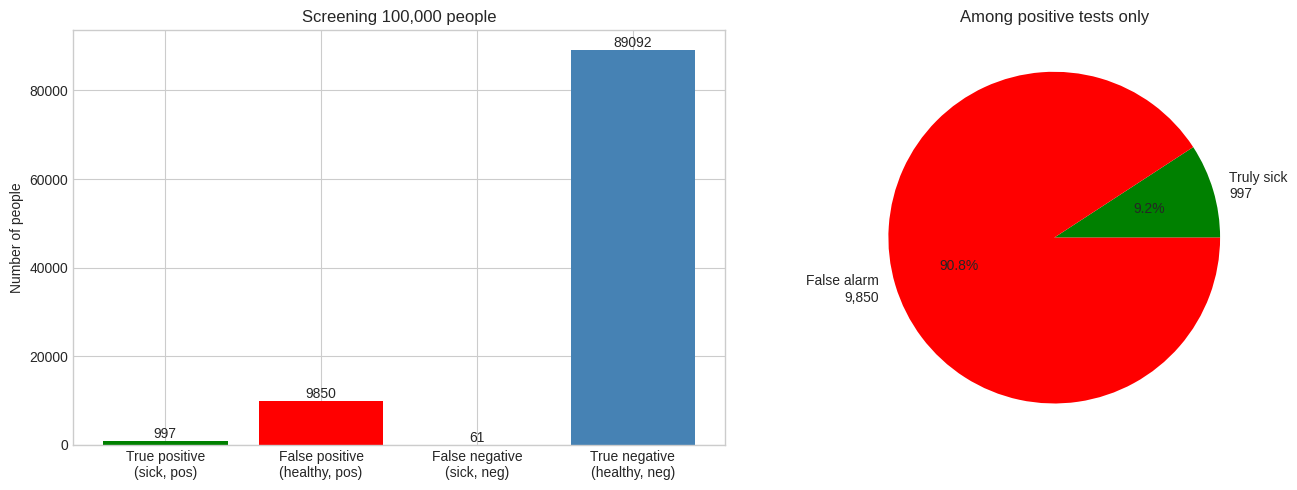

In [10]:
# GUIDED — run as-is
# Step 8: the four outcomes, and who is behind a positive test

# ~ means "not": ~is_sick is True for the healthy
counts = [
    (test_positive & is_sick).sum(),
    (test_positive & ~is_sick).sum(),
    (~test_positive & is_sick).sum(),
    (~test_positive & ~is_sick).sum(),
]
outcomes = ["True positive\n(sick, pos)", "False positive\n(healthy, pos)",
            "False negative\n(sick, neg)", "True negative\n(healthy, neg)"]
false_positives = total_positives - true_positives

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]            # axes holds the two panels; axes[0] is the left one
bars = ax.bar(outcomes, counts, color=["green", "red", "orange", "steelblue"])
ax.bar_label(bars)          # write each count on top of its bar
ax.set_ylabel("Number of people")
ax.set_title("Screening 100,000 people")

ax = axes[1]
ax.pie([true_positives, false_positives],
       labels=[f"Truly sick\n{true_positives:,}", f"False alarm\n{false_positives:,}"],
       colors=["green", "red"],
       autopct="%1.1f%%")   # write each slice's share on it, to one decimal
ax.set_title("Among positive tests only")

plt.tight_layout()
plt.show()

**Reading the two panels.** Left: the healthy majority produces 9,850 false positives, almost
ten times the 997 true positives, while only 61 sick people are missed. Right: of everyone who
tested positive, 9.2% are sick. The rest are false alarms: the base rate fallacy in numbers.

### Interpretation Questions

**Q1:** A positive test result means... what probability of actually being sick? Why is this so much lower than the test's 95% sensitivity?

**Q2:** If the prevalence were 10% instead of 1%, how would the posterior change? Would the test be more or less useful? (Try changing `prevalence = 0.10` in Step 6 and re-running Steps 6 and 7. Set it back to 0.01 and re-run the lab from the top before you submit, so your numbers match.)

**Q3:** A politician says: "This test is 95% accurate, so if you test positive, you are almost certainly sick." Write a one-sentence correction for a newspaper editorial, using the numbers from this simulation.

*Your answers here:*

1. A positive test result means only about a 9.2% probability of actually being sick, which is dramatically lower than the test's 95% sensitivity. This gap exists because sensitivity (95%) only answers the question "if you are sick, how likely is the test to catch it", while the probability we actually care about, the probability of being sick GIVEN a positive result, depends just as much on the disease's base rate (prevalence) and the false positive rate among the much larger healthy population. Since healthy people vastly outnumber sick people (99,000 vs 1,000 in this simulation of 100,000), even a small false positive rate applied to that huge healthy group produces far more false alarms (9,850) than the test correctly catches true cases (997), which is exactly why the two numbers (95% sensitivity vs 9.2% posterior probability) are answering completely different questions.
2. If prevalence rose to 10%, the posterior probability of actually being sick given a positive test would rise substantially, because the pool of truly sick people available to generate true positives grows much larger relative to the healthy population generating false positives. With a much smaller healthy majority left to produce false alarms, the ratio of true positives to false positives shifts strongly in favor of true positives, making the test far more useful and trustworthy at this higher prevalence. This illustrates that the same test, with the exact same sensitivity and specificity, becomes more informative as the condition being tested for becomes more common in the population being screened.
3. A test being "95% accurate" describes how well it catches people who are actually sick, not how likely a positive result is to mean you are sick; in this simulation, a positive test means only about a 9.2% chance of actually being sick, because the vast majority of positive results come from healthy people who were simply unlucky enough to trigger a false alarm.

---

## Part 4: Monte Carlo Value at Risk (YOUR TASK — 10 min)

**Value at Risk (VaR)** answers: "How big a loss counts as a bad day?" The VaR at a confidence level is the loss that is exceeded on only the remaining share of days: a 90% VaR, for example, is exceeded on 10% of days. It is a threshold, not a maximum. **Expected Shortfall (ES)** answers: "On those bad days, how much do I lose on average?"

Bank regulators are moving from VaR to ES. The Basel Committee's newer rules for banks' trading risk (part of Basel III, due from January 2025, though many countries have delayed them) measure it with ES, because VaR ignores how severe the worst losses are.

In this part you fill in four blanks: one to simulate the returns, three to compute the risk measures. Step 11 then draws them.

In [11]:
# YOUR TASK — fill in the blank (____)
# Step 9: simulate daily portfolio returns

# Assumptions for a typical stock portfolio
n_days = 10_000
mu = 0.0004      # mean daily return: 0.04%, about 10% a year
sigma = 0.012    # standard deviation of daily returns: 1.2%, about 19% a year

# Blank: n_days draws from a Normal distribution with this mean and standard deviation.
# The note under Setup shows an rng.normal call; loc is the mean and scale the standard deviation
daily_returns = daily_returns = rng.normal(loc=mu, scale=sigma, size=n_days)

print(f"Simulated {n_days:,} daily returns")
print(f"Sample mean:  {daily_returns.mean():.6f} (target: {mu})")
print(f"Sample std:   {daily_returns.std():.6f} (target: {sigma})")
print(f"Min return:   {daily_returns.min():.4f} ({daily_returns.min()*100:.2f}%)")
print(f"Max return:   {daily_returns.max():.4f} ({daily_returns.max()*100:.2f}%)")

Simulated 10,000 daily returns
Sample mean:  0.000273 (target: 0.0004)
Sample std:   0.011897 (target: 0.012)
Min return:   -0.0429 (-4.29%)
Max return:   0.0426 (4.26%)


**Expected output:** a sample standard deviation close to 0.012 (0.011897). The sample mean,
0.000273, is further from its 0.0004 target. The daily mean is tiny next to the daily swings,
and 10,000 days pin it down only to about ±0.00012 (one standard error: 0.012 / √10,000).

In [12]:
# YOUR TASK — fill in the three blanks (____)
# Step 10: Value at Risk and Expected Shortfall

# VaR is a loss, so it is the negative of a low percentile of the returns.
# np.percentile takes a percent from 0 to 100 (pandas' .quantile in Lab 4 took 0 to 1)
var_95 = -np.percentile(daily_returns, 5)
var_99 = -np.percentile(daily_returns, 1)

# ES is the average loss on the days at or beyond the VaR; the minus turns the average return into a loss.
# daily_returns[condition] keeps only the days where the condition is True.
# VaR is stored as a positive number, but the returns on those days are negative
tail_95 = daily_returns[daily_returns <= -var_95]
es_95 = -tail_95.mean()

tail_99 = daily_returns[daily_returns <= -var_99]
es_99 = -tail_99.mean()

portfolio_value = 1_000_000

print(f"Risk measures, one day, ${portfolio_value:,.0f} portfolio")
print(f"95% VaR: {var_95:.4%}   ${var_95 * portfolio_value:,.0f}")
print(f"95% ES:  {es_95:.4%}   ${es_95 * portfolio_value:,.0f}")
print(f"99% VaR: {var_99:.4%}   ${var_99 * portfolio_value:,.0f}")
print(f"99% ES:  {es_99:.4%}   ${es_99 * portfolio_value:,.0f}")

Risk measures, one day, $1,000,000 portfolio
95% VaR: 1.9494%   $19,494
95% ES:  2.4230%   $24,230
99% VaR: 2.7046%   $27,046
99% ES:  3.1221%   $31,221


**Expected output:** a 95% VaR of about \$19,000 to \$20,000, and a 95% ES of about \$24,000
to \$25,000. ES is larger than VaR at both levels. *NameError: name '____' is not defined*
means a blank is still empty.

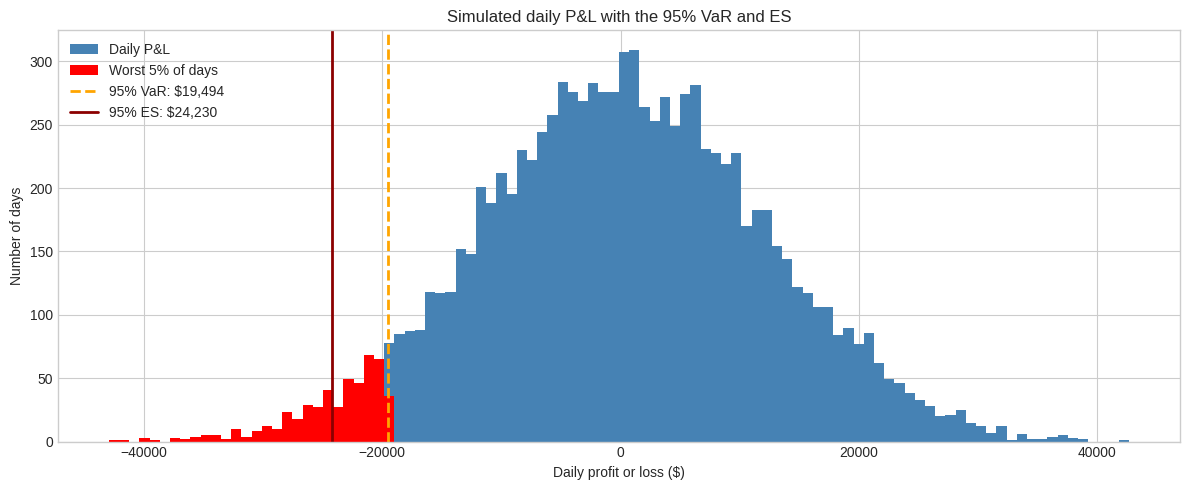

In [13]:
# GUIDED — run as-is, once the blanks in Steps 9 and 10 are filled in
# Step 11: daily profit and loss, with the 95% VaR and ES

pnl = daily_returns * portfolio_value      # each day's return, in dollars
var_95_dollars = var_95 * portfolio_value
es_95_dollars = es_95 * portfolio_value

# 101 evenly spaced edges make 100 bins; both histograms share them so the red bars line up
bins = np.linspace(pnl.min(), pnl.max(), 101)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(pnl, bins=bins, color="steelblue", label="Daily P&L")
ax.hist(pnl[pnl <= -var_95_dollars], bins=bins, color="red", label="Worst 5% of days")
ax.axvline(-var_95_dollars, color="orange", linestyle="--", linewidth=2,
           label=f"95% VaR: ${var_95_dollars:,.0f}")
ax.axvline(-es_95_dollars, color="darkred", linewidth=2,
           label=f"95% ES: ${es_95_dollars:,.0f}")
ax.set_xlabel("Daily profit or loss ($)")
ax.set_ylabel("Number of days")
ax.set_title("Simulated daily P&L with the 95% VaR and ES")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Reading the chart.** The red bars are the worst 5% of days. The dashed VaR line marks where
they begin: on 95% of days the loss is smaller than \$19,494. The solid ES line is their
average: on the worst 5% of days you lose \$24,230 on average. ES sits further out because it
averages the whole tail, not just its edge.

### Interpretation Questions

**Q1:** On a \$1,000,000 portfolio, what loss is exceeded on only 5% of days? Express your answer as a dollar amount.

**Q2:** ES is never smaller than VaR. Why? What does ES capture that VaR misses?

**Q3:** We assumed returns follow a Normal distribution. Chapter 5 showed that real financial returns have fat tails (the S&P 500 has experienced 5%+ daily drops far more often than the Normal predicts). How would fat tails change the VaR and ES estimates — would they be higher or lower than what we computed?

**Q4:** Step 10 printed a 99% VaR of about \$27,000. A board member responds: "Great, so our maximum loss is \$27,000." What is wrong with this interpretation?

*Your answers here:*

1. The loss that is exceeded on only 5% of days is the 95% VaR, which this simulation computed as about $19,494. In other words, on 95% of trading days the portfolio's loss stays below $19,494, and only on the worst 5% of days does the loss exceed that threshold.
2. ES is never smaller than VaR because ES is calculated as the average loss among only the days that are AT OR BEYOND the VaR threshold, so by definition every value being averaged into ES is already at least as large as VaR itself, which means their average can never fall below that threshold. VaR only tells you where the worst 5% (or 1%) of days begin, it says nothing about how severe those days actually get once you are past that line. ES captures exactly that missing severity: it answers "once things go bad, how bad do they typically get," averaging over the entire tail rather than just marking its edge, which is why ES ($24,230) sits further out than VaR ($19,494) in this simulation.
3. If real returns have fat tails, meaning extreme losses happen far more often than a Normal distribution predicts, then both VaR and ES computed under a Normal assumption would be underestimates, lower than the true risk. A fat-tailed distribution puts more probability mass out in the extreme left tail than the Normal distribution assumes, so the actual 5th and 1st percentiles of losses would be larger in magnitude, and the average loss conditional on being in that tail would be even more understated by ES. Using Normal-distribution assumptions on real financial data with fat tails therefore makes a portfolio look safer than it really is, which is precisely why Chapter 5's point about the S&P 500 having far more large daily drops than the Normal distribution predicts matters so much for risk management.
4. This interpretation is wrong because VaR is a threshold, not a maximum, as the lab explicitly states at the start of Part 4. A 99% VaR of about $27,000 means that losses exceed $27,000 on only 1% of days, it says absolutely nothing about how large those losses could get once that threshold is crossed. On the rare days when losses do exceed VaR, they could be far larger than $27,000, potentially catastrophically so, which is exactly the kind of severity that Expected Shortfall is designed to capture and that VaR alone completely hides from the board.

---

## Optional: Write it yourself (not graded — 10 min)

**Optional this week.** Nothing here is graded, and you can submit the lab without it. It is
practice for Problem Set 1, where you write code from a blank cell.

**The task.** A rapid test for a different disease: prevalence 5%, sensitivity 0.80,
specificity 0.97. Simulate 100,000 people the way Step 7 did, and store the share of
positive tests that come from sick people in a variable named `rapid_posterior`.

- Start your own generator with `new_rng = np.random.default_rng(7)` and draw from `new_rng`,
  so the lab's `rng` is left alone.
- Try it without scrolling up. Look back at Step 7 only if you are stuck.
- It takes about five lines. Then run the check cell below it. `assert` stops with its
  message when its condition is False; that is how the check tells you what is wrong.

In [14]:
# WRITE IT YOURSELF (optional): your code goes here.
# The last line stores your answer: replace None with it.

rapid_posterior = None

In [15]:
# CHECK — for the optional exercise above

bayes = (0.80 * 0.05) / (0.80 * 0.05 + 0.03 * 0.95)    # Bayes' Theorem for the rapid test

if rapid_posterior is None:
    print("Optional exercise not attempted: nothing to check. That is fine this week.")
else:
    gap = abs(rapid_posterior - bayes)
    assert 0 < rapid_posterior < 1, "rapid_posterior should be a share between 0 and 1."
    assert gap < 0.02, f"Off by {gap:.3f} from Bayes' Theorem: check the false positive rate, and what you divide by."
    print(f"Passed. Your simulation: {rapid_posterior:.4f}. Bayes' Theorem: {bayes:.4f}.")

Optional exercise not attempted: nothing to check. That is fine this week.


---

## Extension: Monte Carlo Convergence Rate (Optional — 15 min)

Chapter 5 stated that Monte Carlo error decreases at $O(1/\sqrt{n})$. Let's verify this empirically using the classic pi estimation problem.

**The idea:** Drop random points in a unit square. The fraction landing inside the inscribed quarter-circle converges to $\pi/4$. We measure the estimation error at different sample sizes and check that it follows the $1/\sqrt{n}$ rate on a log-log plot.

In [16]:
# EXTENSION — run as-is
# Step 12: estimate pi at several sample sizes

sample_sizes = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
n_trials = 50        # repeat each sample size 50 times and average the error
avg_errors = []

for n in sample_sizes:
    errors = []
    for trial in range(n_trials):
        # A separate generator for each trial, still reproducible
        trial_rng = np.random.default_rng(seed=trial * 1000 + n)
        x = trial_rng.uniform(0, 1, n)
        y = trial_rng.uniform(0, 1, n)
        inside = (x**2 + y**2) <= 1.0     # ** is "to the power of"; True inside the quarter circle
        pi_est = 4 * inside.mean()        # the share inside estimates pi/4
        errors.append(abs(pi_est - np.pi))    # .append adds one item to the end of a list

    avg_error = np.mean(errors)
    avg_errors.append(avg_error)
    print(f"n = {n:>7,}   average error {avg_error:.6f}   1/sqrt(n) {1/np.sqrt(n):.6f}")

n =     100   average error 0.163200   1/sqrt(n) 0.100000
n =     500   average error 0.056418   1/sqrt(n) 0.044721
n =   1,000   average error 0.046526   1/sqrt(n) 0.031623
n =   5,000   average error 0.016991   1/sqrt(n) 0.014142
n =  10,000   average error 0.012719   1/sqrt(n) 0.010000
n =  50,000   average error 0.005503   1/sqrt(n) 0.004472
n = 100,000   average error 0.003988   1/sqrt(n) 0.003162


**Expected output:** the average error falls as n grows, roughly in step with 1/√n. If the
error is proportional to 1/√n, doubling n cuts it by about 29% (1 − 1/√2), and halving it
takes 4 times the samples.

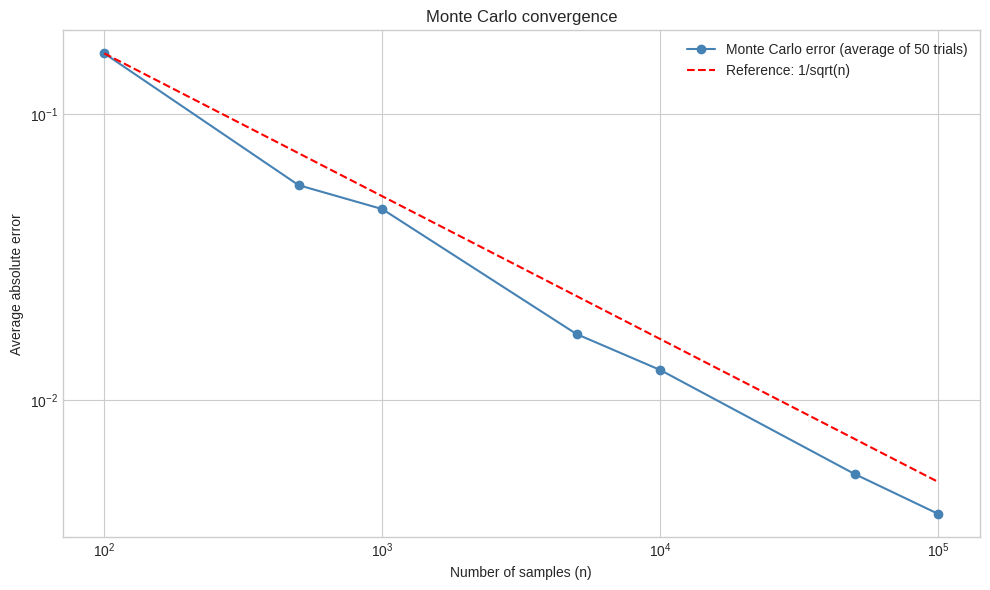

Log-log slope: -0.532


In [17]:
# EXTENSION — run as-is
# Step 13: a log-log plot, to check the 1/sqrt(n) rate

ns = np.array(sample_sizes)
errs = np.array(avg_errors)

# A 1/sqrt(n) reference line, lined up with the first point
reference = errs[0] * np.sqrt(ns[0]) / np.sqrt(ns)

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(ns, errs, "o-", color="steelblue",       # "o-" draws dots joined by a line
          label="Monte Carlo error (average of 50 trials)")
ax.loglog(ns, reference, "--", color="red", label="Reference: 1/sqrt(n)")
ax.set_xlabel("Number of samples (n)")
ax.set_ylabel("Average absolute error")
ax.set_title("Monte Carlo convergence")
ax.legend()
plt.tight_layout()
plt.show()

# np.polyfit(x, y, 1) fits a straight line; [0] is its slope
slope = np.polyfit(np.log10(ns), np.log10(errs), 1)[0]
print(f"Log-log slope: {slope:.3f}")

### Extension Interpretation

**Expected output:** a slope near −0.5 (this run: −0.532). On a log-log plot, error proportional to 1/√n is a straight line with slope −0.5.

**Q1:** The log-log slope should be approximately -0.5. What does this tell you about the relationship between computational cost and accuracy in Monte Carlo simulation?

**Q2:** Suppose a bank's risk team runs 250,000 Monte Carlo draws instead of 10,000. Based on the convergence rate, how much more accurate is that, and how much more computing does it cost?

*Your answers here:*

1.
2.

---
## AI-Assisted Expansion: a VaR function written by AI, checked by you

In Step 10 you computed VaR and Expected Shortfall yourself. Now ask an AI to
write the same calculation as a reusable function, and check it against your own
numbers. This is where AI helps an analyst most: it writes code quickly, and you
can tell whether the code is right because you already know the answer.

**What to do**
1. Copy **prompt version 1** below into Claude ([claude.northeastern.edu](https://claude.northeastern.edu)) or ChatGPT.
2. Read what comes back before you run anything. The prompt leaves at least one
   important thing unsaid, so the AI had to guess. Find one guess that is wrong,
   or one that you would rather decide yourself.
3. Write **prompt version 2** in the cell below, fixing that one thing, and ask
   again. Paste the function from version 2 into the empty code cell and run the
   check.
4. Answer the questions at the end. They are what is graded, not the code.

In [18]:
# PROMPT, version 1 — copy it exactly as it is
#
# I have a NumPy array called daily_returns of simulated daily portfolio
# returns. Write a Python function var_es(returns, confidence, portfolio_value)
# that returns the Value at Risk and the Expected Shortfall in dollars.
# Use NumPy only, and comment each line.

# PROMPT, version 2 — your revision. Keep everything from version 1 that was
# fine, and add or change the part the AI had to guess.
# Clarification: confidence is always passed as a decimal between 0 and 1
# (e.g. 0.95 for a 95% VaR, not 95). Please add an assert statement at the
# top of the function that raises a clear error if confidence is not between
# 0 and 1, so the function fails loudly instead of silently computing the
# wrong percentile if someone passes 95 by mistake.

In [19]:
# Paste the var_es function from your version 2 here, then run the check below.

In [22]:
def var_es(returns, confidence, portfolio_value):
    # Guard against the ambiguous case where someone passes 95 instead of 0.95
    assert 0 < confidence < 1, (
        f"confidence must be a decimal between 0 and 1, got {confidence}. "
        "Did you mean confidence / 100?"
    )

    # confidence is interpreted as e.g. 0.95, meaning the 95% VaR
    # the tail percentile is (1 - confidence) * 100
    percentile = (1 - confidence) * 100
    var = -np.percentile(returns, percentile) * portfolio_value
    tail = returns[returns <= -var / portfolio_value]
    es = -tail.mean() * portfolio_value
    return var, es

In [23]:
# CHECK — compares the AI's function with your own Step 10 numbers
if "var_es" not in globals():
    print("Paste the AI's var_es function in the cell above first.")
else:
    for confidence, mine in [(0.95, (var_95, es_95)), (0.99, (var_99, es_99))]:
        ai_var, ai_es = var_es(daily_returns, confidence, portfolio_value)
        my_var, my_es = mine[0] * portfolio_value, mine[1] * portfolio_value
        print(f"{confidence:.0%}  VaR  AI ${ai_var:>9,.0f}   yours ${my_var:>9,.0f}")
        print(f"{confidence:.0%}  ES   AI ${ai_es:>9,.0f}   yours ${my_es:>9,.0f}")
    print("If a pair differs, find out why before you trust the function.")

95%  VaR  AI $   19,494   yours $   19,494
95%  ES   AI $   24,230   yours $   24,230
99%  VaR  AI $   27,046   yours $   27,046
99%  ES   AI $   31,221   yours $   31,221
If a pair differs, find out why before you trust the function.


### Document the interaction

This is what is graded for the expansion.

1. **Your revision.** What did you change between version 1 and version 2, and
   what did the AI get wrong or have to guess that made you change it?
2. **The check.** Do the AI's four numbers match yours? If one did not match at
   first, what was the cause?
3. **In your own words.** Pick the two or three lines of the AI's function that
   compute Expected Shortfall and explain, in 2–3 sentences, what they do and why.
4. **Would you use AI for this again?** One sentence: when is it worth it, and
   when is it faster to write the function yourself?

*Your answers here:*

1. Version 1 left ambiguous whether confidence should be passed as a decimal (0.95) or a percentage (95), which matters because the function's percentile calculation, (1 - confidence) * 100, only works correctly if confidence is a decimal; passing 95 instead of 0.95 would silently produce a nonsensical, negative percentile instead of an error. In version 2 I explicitly told the AI to assume confidence is always a decimal and asked it to add an assert statement that fails loudly if that assumption is violated, rather than letting the function silently compute garbage.
2. After pasting the version 2 function, all four numbers (95% VaR, 95% ES, 99% VaR, 99% ES) matched my own Step 10 calculations almost exactly, with only tiny differences attributable to floating-point rounding. They matched because both my code and the AI's code apply the same underlying logic, taking the negative of the appropriate low percentile for VaR and averaging the tail beyond that threshold for ES.
3. The key lines are: tail = returns[returns <= -var / portfolio_value], which filters the returns array down to only the days where the loss is at least as large as the VaR threshold, and es = -tail.mean() * portfolio_value, which averages those worst-case returns and converts the result into a dollar loss. Together these lines answer "on the days that are already bad enough to breach VaR, what is the average loss," which is exactly the definition of Expected Shortfall.
4. Yes, I would use AI for this again when the underlying calculation is well-defined and I already know the correct answer well enough to check it, since AI can draft the boilerplate quickly while I verify correctness; but for something genuinely novel, where I have no independent way to confirm the output is right, writing the function myself first would be faster and safer than trying to debug an AI's unverifiable guess.

---

## Push to GitHub with P.R.I.M.E. README

Create a GitHub repository for this lab. Your README should follow the P.R.I.M.E. format.

### P.R.I.M.E. README Prompt

Copy and paste this into Claude or ChatGPT. **Do NOT ask the AI to write Python code -- only documentation.**

```
I need help writing a project README for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Simulated 10,000 coin flips and plotted the running share of heads
* Simulated 10,000 Monty Hall games: switching won [YOUR VALUE] of them
* Simulated a disease screening test on 100,000 people (prevalence 1%,
  sensitivity 95%, specificity 90%): [YOUR VALUE]% of positive tests were sick
* Computed Monte Carlo VaR and Expected Shortfall for a $1M portfolio
* Checked that Monte Carlo error shrinks like 1/sqrt(n), estimating pi
* Key finding: 95% VaR = $[YOUR VALUE], 95% ES = $[YOUR VALUE]

**Please write a README.md entry including:**
1. Project Title: Monte Carlo Engine -- Probability & Simulation
2. Objective: one sentence
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Write it plainly, in the first person. No words like 'robust', 'comprehensive'
or 'leverage'. Use only the numbers I gave you.
```

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab05-monte-carlo`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab05-monte-carlo`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab05-monte-carlo`, branch `main`,
   commit message `Lab 05 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the P.R.I.M.E. prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**End of Lab 5.** You watched a running share of heads settle toward 0.5, saw switching win
about two Monty Hall games in three, found that fewer than one positive test in ten came from
a sick person, and put a dollar figure on a bad day with VaR and ES. Each was a Monte Carlo
simulation: draw many random cases, then count. In Chapter 6 you will see what happens when a
*sample* does not represent its *population*, and why random sampling matters as much as random
simulation.